# Task 1: Datasets and Dataloaders


In [1]:
print("Notebook started", flush=True)
import random
from collections import Counter
import pickle

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import datasets, models, transforms
from torchvision.datasets import STL10
from torchvision.transforms import ToTensor
from torchvision.transforms import functional as TF

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


Notebook started


Seeds + checking that our GPU is connected to the notebook 

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator().manual_seed(SEED)

# Check PyTorch and CUDA versions
print("Torch version:", torch.__version__, flush=True)
print("CUDA available:", torch.cuda.is_available(), flush=True)
print("CUDA version:", torch.version.cuda, flush=True)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None", flush=True)

Torch version: 2.2.2+cu121


CUDA available: True


CUDA version: 12.1


GPU: NVIDIA L40S


# Image rotation and class balance check

Importing the dataset, which was previously downloaded using the STL10 function 

In [3]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), #resnet wants 224X224 format, need to resize 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # additionally want to normalize --> normalisation values online 
                         std=[0.229, 0.224, 0.225])])

stl_unlabeled = STL10(
    root="/users/jmatthia/deep_learning/data",
    split="unlabeled",
    download=True,
    transform=None)

Files already downloaded and verified


Image rotation: for each base image it emits fours samples, which are rotated by 0/90/180/270 --> {0 → 0°, 1 → 90°, 2 → 180°, 3 → 270°}

In [4]:
class RotationDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform
        self.angles = [0, 90, 180, 270]

    def __len__(self):
        return len(self.base_dataset) * 4

    def __getitem__(self, idx):
        real_idx = idx % len(self.base_dataset)
        img, _ = self.base_dataset[real_idx]

        # 2. Assign rotation label based on index (ensures perfect balance)
        rotation_label = idx % 4
        angle = self.angles[rotation_label]

        # 3. Rotate the image
        rotated_img = TF.rotate(img, angle)

        # Apply any transforms (resizing to 224x224 for AlexNet, normalization, etc.)
        if self.transform is not None:
            rotated_img = self.transform(rotated_img)

        return rotated_img, rotation_label

Creating the train and validation set

In [5]:
val_frac = 0.1
n_total = len(stl_unlabeled)
n_val = int(n_total * val_frac)
n_train = n_total - n_val

# Random split of unlabeles into train and validation 
base_train, base_val = random_split(stl_unlabeled, [n_train, n_val], generator=g)

# Create the labels based on image rotation
rot_train_ds = RotationDataset(base_train, transform_train)
rot_val_ds   = RotationDataset(base_val,   transform_train)

#dataloader function 
rot_train_loader = DataLoader(rot_train_ds, batch_size=256, shuffle=True,  num_workers=4, pin_memory=True, generator=g)
rot_val_loader   = DataLoader(rot_val_ds,   batch_size=256, shuffle=False, num_workers=4, pin_memory=True, generator=g)

Checking that the train set is correct and labels are balanced

In [6]:
print("Base train:", len(base_train), " Base val:", len(base_val))
print("Rot train:", len(rot_train_ds), " Rot val:", len(rot_val_ds))
assert len(rot_train_ds) == 4 * len(base_train)
assert len(rot_val_ds)   == 4 * len(base_val)


# Check only the first 10,000 samples 
sample_size = 20000 

print(f"Checking balance on a sample of {sample_size}...")
train_counts = Counter(rot_train_ds[i][1] for i in range(sample_size))
print("--- TRAIN BALANCE (Sampled) ---")
# If you don't have the check_balance function defined from my previous message:
for label, count in sorted(train_counts.items()):
    print(f"Label {label}: {count} ({count/sample_size*100:.2f}%)")

print(f"Checking balance on a sample of {sample_size}...")
val_counts = Counter(rot_val_ds[i][1] for i in range(sample_size))
print("--- VALIDATION BALANCE (Sampled) ---")
# If you don't have the check_balance function defined from my previous message:
for label, count in sorted(val_counts.items()):
    print(f"Label {label}: {count} ({count/sample_size*100:.2f}%)")

Base train: 90000  Base val: 10000
Rot train: 360000  Rot val: 40000
Checking balance on a sample of 20000...


--- TRAIN BALANCE (Sampled) ---
Label 0: 5000 (25.00%)
Label 1: 5000 (25.00%)
Label 2: 5000 (25.00%)
Label 3: 5000 (25.00%)
Checking balance on a sample of 20000...


--- VALIDATION BALANCE (Sampled) ---
Label 0: 5000 (25.00%)
Label 1: 5000 (25.00%)
Label 2: 5000 (25.00%)
Label 3: 5000 (25.00%)


Sample of images which have been rotated, to check if the rotation labels are correct

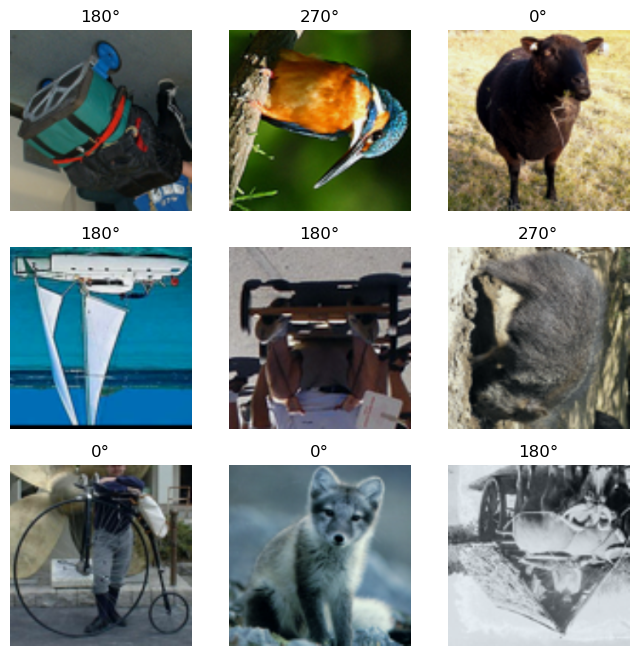

In [7]:
labels_map = {
    0: "0°",
    1: "90°",
    2: "180°",
    3: "270°"
}

mean = torch.tensor([0.4467, 0.4398, 0.4066])
std  = torch.tensor([0.2241, 0.2215, 0.2239])

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

def denorm(img): 
    return img * std[:, None, None] + mean[:, None, None]

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(rot_train_ds), size=(1,)).item()
    img, label = rot_train_ds[sample_idx]   # TENSOR, normalized

    img = denorm(img).permute(1, 2, 0).clamp(0, 1)

    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img)

plt.show()

# Model creation and hyperparameter specifications

Creating the model, I chose ResNet 18. The weights are set to random 

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MODEL setup here --> using resnet + 
model = models.resnet18(weights=None)# resnet model --> no pretraining, random init
#model = models.resnet18(weights=False)  
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 4)   # rotation head (in.features is what us coming in and 4 is the output)
model = model.to(device)

Here, I choose the loss function, learning rate, and weight decay. I initially had a lot of difficulty here, as my model was overfitting very fast. I tried to increase regularisation, and increase performance on the subsequent transfer learning task. At the end these were the hyperparameters which yielded superior performance both in preventing overfitting (which is still a present) and in the subsequent transfer learning task. 

For the loss function I use cross entropy loss, which is a standard loss function for multi-class classifications. As our optimizer I choose stochastic gradient descent with a momentum of 0.9 which helps in smoothing gradient updates. It does this by accumulating past gradients, which in turn should help reduce erratic jumps. Weight decay functions as a regularsation term, where large weights are penalized. For the learning rate I choose the StepLR, which changes the learning rate by a factor of 10 after 10 epochs. This in theory, should help us refine more and more the model. 


In [9]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

Defining the train and val function. This is where the weights of the model are updated. 

In [10]:
def run_epoch(model, loader, optimizer=None):
    print("loader dataset id:", id(loader.dataset), "len:", len(loader.dataset))
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_correct, total_n = 0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if is_train:
                optimizer.zero_grad() # clears old gradients 

            pred = model(x) # make prediction with the model 
            loss = loss_function(pred, y) # softmax  + loss against the actual y 

            if is_train:
                loss.backward() # backpropagate the loss to compute gradients
                optimizer.step() # now we need to update the model weights (actually change them)

            total_loss += loss.item() * x.size(0) # average loss per sample 
            total_correct += (pred.argmax(1) == y).sum().item()
            total_n += x.size(0)
    
    return total_loss / total_n, total_correct / total_n

This function show the prediction accuracy for each class. I used this, as I wanted to check if one class had become very easy to predict 

In [11]:
def per_class_acc(model, loader, n_classes=4):
    model.eval()
    correct = torch.zeros(n_classes, device=device)
    total   = torch.zeros(n_classes, device=device)

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            for c in range(n_classes):
                m = (y == c)
                correct[c] += (pred[m] == y[m]).sum()
                total[c] += m.sum()

    return (correct / total).detach().cpu().numpy()

# Training and saving the model

Here I am training my model and printing out the train and validation loss 

In [12]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []

epochs = 50

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = run_epoch(model, rot_train_loader, optimizer=optimizer) # run on the train for this epoch
    va_loss, va_acc = run_epoch(model, rot_val_loader, optimizer=None) # run on a validation epoch to see how we are doing
    scheduler.step() 

    print("Train per-class:", per_class_acc(model, rot_train_loader))
    print("Val per-class:", per_class_acc(model, rot_val_loader))

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    print(f"Epoch {epoch:03d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}", flush=True)
    

loader dataset id: 140316360106928 len: 360000


loader dataset id: 140316360106496 len: 40000


Train per-class: [0.6272445  0.7196     0.7054667  0.69915557]


Val per-class: [0.6252 0.7228 0.6904 0.7032]
Epoch 001 | train loss 1.0561 acc 0.5555 | val loss 0.8145 acc 0.6854


loader dataset id: 140316360106928 len: 360000


...

Val per-class: [0.8396 0.8332 0.8296 0.83  ]
Epoch 049 | train loss 0.0010 acc 1.0000 | val loss 0.5732 acc 0.8331


loader dataset id: 140316360106928 len: 360000


loader dataset id: 140316360106496 len: 40000


Train per-class: [1. 1. 1. 1.]


Val per-class: [0.8384 0.836  0.8292 0.828 ]
Epoch 050 | train loss 0.0010 acc 1.0000 | val loss 0.5731 acc 0.8329


After running the model and updating its weights, we need to save the backbone 

In [13]:
# Save full model too (optional, useful)
torch.save(model.state_dict(), "/users/jmatthia/deep_learning/models/ssl_rotation_full_model_resnet18_60_epochs.pth")

# Save backbone only (remove fc weights)
backbone_state = {k: v for k, v in model.state_dict().items() if not k.startswith("fc.")}
torch.save(backbone_state, "/users/jmatthia/deep_learning/models/ssl_backbone_resnet18_60_epochs.pth")
print("Saved backbone -> ssl_backbone_resnet18.pth")

Saved backbone -> ssl_backbone_resnet18.pth


Quick graph to show train vs validation curves. Overall shows that the model has indeed learned something.

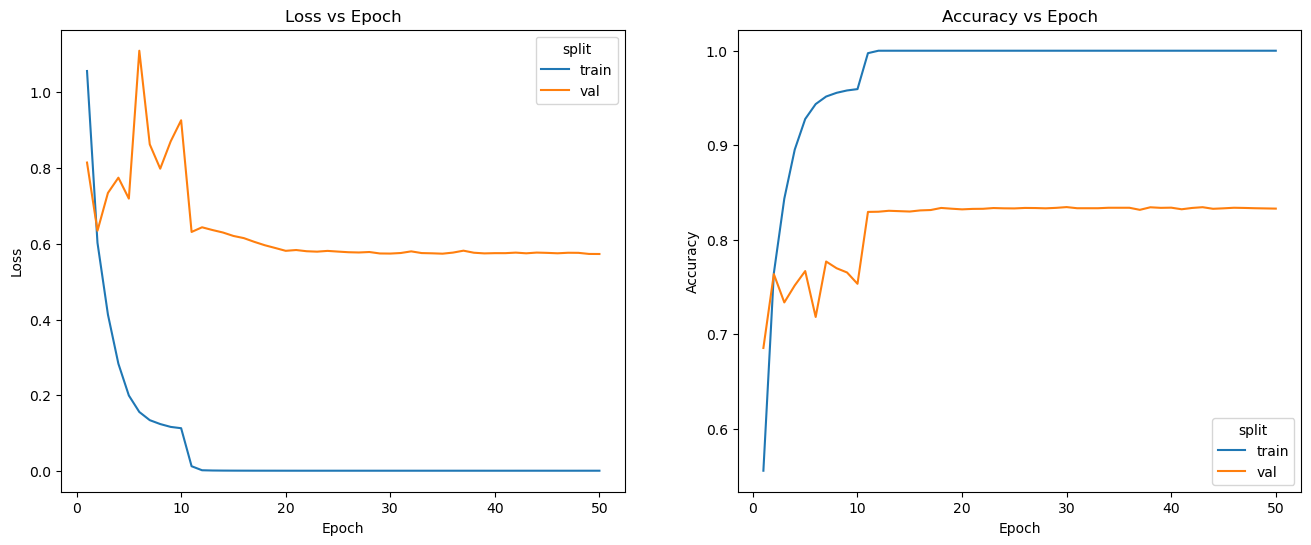

In [14]:
epochs = range(1, len(train_losses) + 1)

plot_df = pd.DataFrame({
    "epoch": list(epochs) * 2,
    "loss": train_losses + val_losses,
    "accuracy": train_accs + val_accs,
    "split": ["train"] * len(train_losses) + ["val"] * len(val_losses)})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# --- Loss ---
sns.lineplot(data=plot_df, x="epoch", y="loss", hue="split", ax=axes[0])
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# --- Accuracy ---
sns.lineplot(data=plot_df, x="epoch",y="accuracy", hue="split",ax=axes[1])
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

out = "/users/jmatthia/deep_learning/code/ssl_train_curves_new_param.png"
fig.savefig(out, dpi=400, bbox_inches="tight")  
plt.show()
plt.close(fig)
